In [0]:
# ============================================
# DASHBOARD: Business Analytics Visualizations
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("📊 RETAIL SALES DASHBOARD")
print("=" * 60)
print("Loading data for visualizations...")

# Load all gold tables as pandas
monthly_pdf = spark.table("retail_lakehouse.gold_monthly_summary").toPandas()
product_pdf = spark.table("retail_lakehouse.gold_product_performance").toPandas()
country_pdf = spark.table("retail_lakehouse.gold_country_sales").toPandas()
customer_pdf = spark.table("retail_lakehouse.gold_customer_analysis").toPandas()
daily_pdf = spark.table("retail_lakehouse.gold_daily_sales").toPandas()

print("✅ All data loaded!")

📊 RETAIL SALES DASHBOARD
Loading data for visualizations...
✅ All data loaded!



📈 CHART 1: Monthly Revenue Trend
----------------------------------------


/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684193-2451785762:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(monthly_pdf['Label'], rotation=45)
/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684193-2451785762:41: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


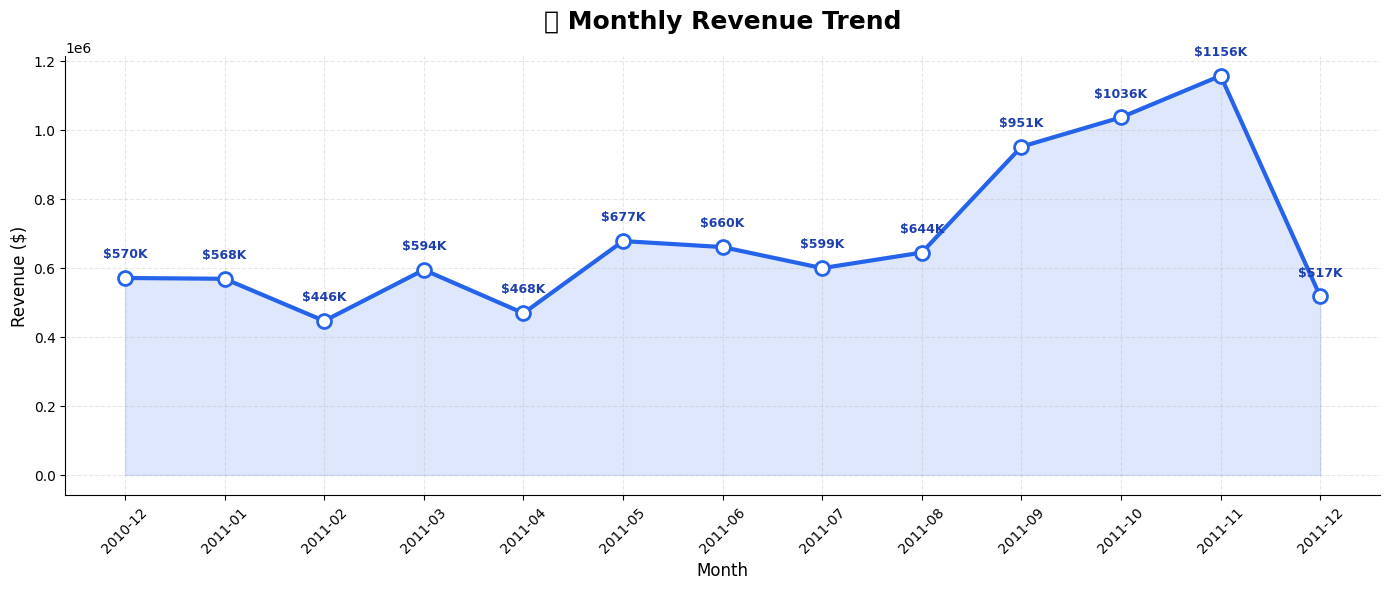

💰 Total Revenue: $8,887,208.89
📊 Avg Monthly Revenue: $683,631.45


In [0]:
print("\n📈 CHART 1: Monthly Revenue Trend")
print("-" * 40)

# Sort by date
monthly_pdf = monthly_pdf.sort_values(['Year', 'Month'])
monthly_pdf['Label'] = monthly_pdf['Year'].astype(str) + '-' + \
                        monthly_pdf['Month'].astype(str).str.zfill(2)

# Create the chart
fig, ax = plt.subplots(figsize=(14, 6))

# Main revenue line
ax.plot(monthly_pdf['Label'], monthly_pdf['Monthly_Revenue'], 
        marker='o', linewidth=3, color='#2563EB', markersize=10,
        markerfacecolor='white', markeredgewidth=2)

# Fill area under line
ax.fill_between(range(len(monthly_pdf)), monthly_pdf['Monthly_Revenue'], 
                 alpha=0.15, color='#2563EB')

# Add value labels on points
for i, (label, value) in enumerate(zip(monthly_pdf['Label'], 
                                        monthly_pdf['Monthly_Revenue'])):
    ax.annotate(f'${value/1000:.0f}K', 
                (i, value), 
                textcoords="offset points",
                xytext=(0, 15), 
                ha='center',
                fontsize=9,
                fontweight='bold',
                color='#1E40AF')

ax.set_title('📈 Monthly Revenue Trend', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue ($)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticklabels(monthly_pdf['Label'], rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print stats
total_rev = monthly_pdf['Monthly_Revenue'].sum()
avg_rev = monthly_pdf['Monthly_Revenue'].mean()
print(f"💰 Total Revenue: ${total_rev:,.2f}")
print(f"📊 Avg Monthly Revenue: ${avg_rev:,.2f}")


📦 CHART 2: Top 10 Products by Revenue
----------------------------------------


/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684194-2395395470:31: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


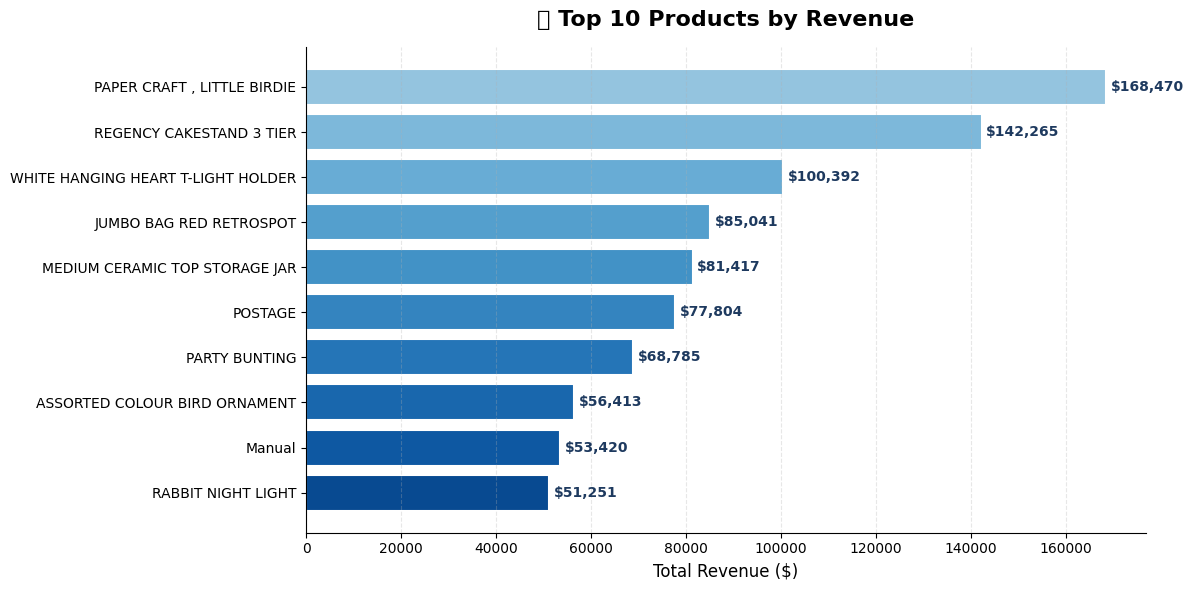

🏆 Best Product: PAPER CRAFT , LITTLE BIRDIE
   Revenue: $168,469.60


In [0]:
print("\n📦 CHART 2: Top 10 Products by Revenue")
print("-" * 40)

# Get top 10
top10_products = product_pdf.nlargest(10, 'Total_Revenue')[['Description', 'Total_Revenue']]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Color gradient
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))

bars = ax.barh(range(len(top10_products)), top10_products['Total_Revenue'], 
               color=colors, edgecolor='white', linewidth=1.5)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, top10_products['Total_Revenue'])):
    ax.text(value + 1000, bar.get_y() + bar.get_height()/2,
            f'${value:,.0f}',
            va='center', fontsize=10, fontweight='bold', color='#1E3A5F')

ax.set_yticks(range(len(top10_products)))
ax.set_yticklabels(top10_products['Description'], fontsize=10)
ax.invert_yaxis()
ax.set_title('🏆 Top 10 Products by Revenue', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue ($)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--', axis='x')

plt.tight_layout()
plt.show()

# Best product
best = top10_products.iloc[0]
print(f"🏆 Best Product: {best['Description']}")
print(f"   Revenue: ${best['Total_Revenue']:,.2f}")


🌍 CHART 3: Sales Distribution by Country
----------------------------------------


/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684195-2932058416:47: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


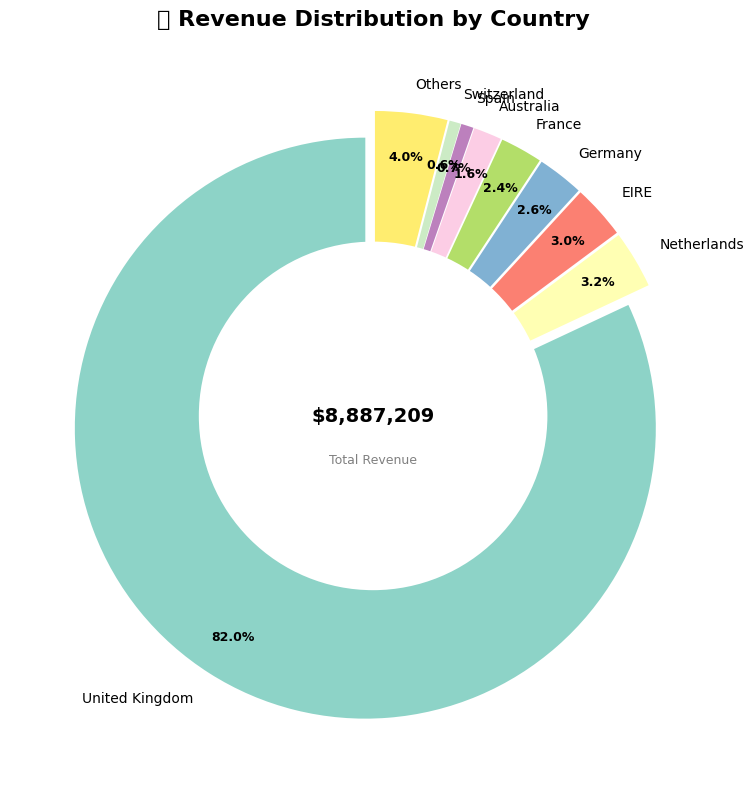

🌍 Top Market: United Kingdom
   Revenue: $7,285,024.64


In [0]:
print("\n🌍 CHART 3: Sales Distribution by Country")
print("-" * 40)

# Get top 8 countries, group rest as "Others"
top_countries = country_pdf.nlargest(8, 'Total_Revenue')
others_revenue = country_pdf['Total_Revenue'].sum() - top_countries['Total_Revenue'].sum()

# Prepare data for pie chart
pie_labels = list(top_countries['Country']) + ['Others']
pie_values = list(top_countries['Total_Revenue']) + [others_revenue]

# Color palette
colors = plt.cm.Set3(np.linspace(0, 1, len(pie_labels)))

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    pie_values, 
    labels=pie_labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    explode=[0.05] * len(pie_labels)
)

# Style the labels
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

# Add center circle for donut effect
centre_circle = plt.Circle((0, 0), 0.60, fc='white', linewidth=0)
ax.add_artist(centre_circle)

# Add total in center
ax.text(0, 0, f'${country_pdf["Total_Revenue"].sum():,.0f}',
        ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(0, -0.15, 'Total Revenue',
        ha='center', va='center', fontsize=9, color='gray')

ax.set_title('🌍 Revenue Distribution by Country', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Top country
top_country = top_countries.iloc[0]
print(f"🌍 Top Market: {top_country['Country']}")
print(f"   Revenue: ${top_country['Total_Revenue']:,.2f}")


👥 CHART 4: Customer Segmentation
----------------------------------------


/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684196-3545606077:53: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


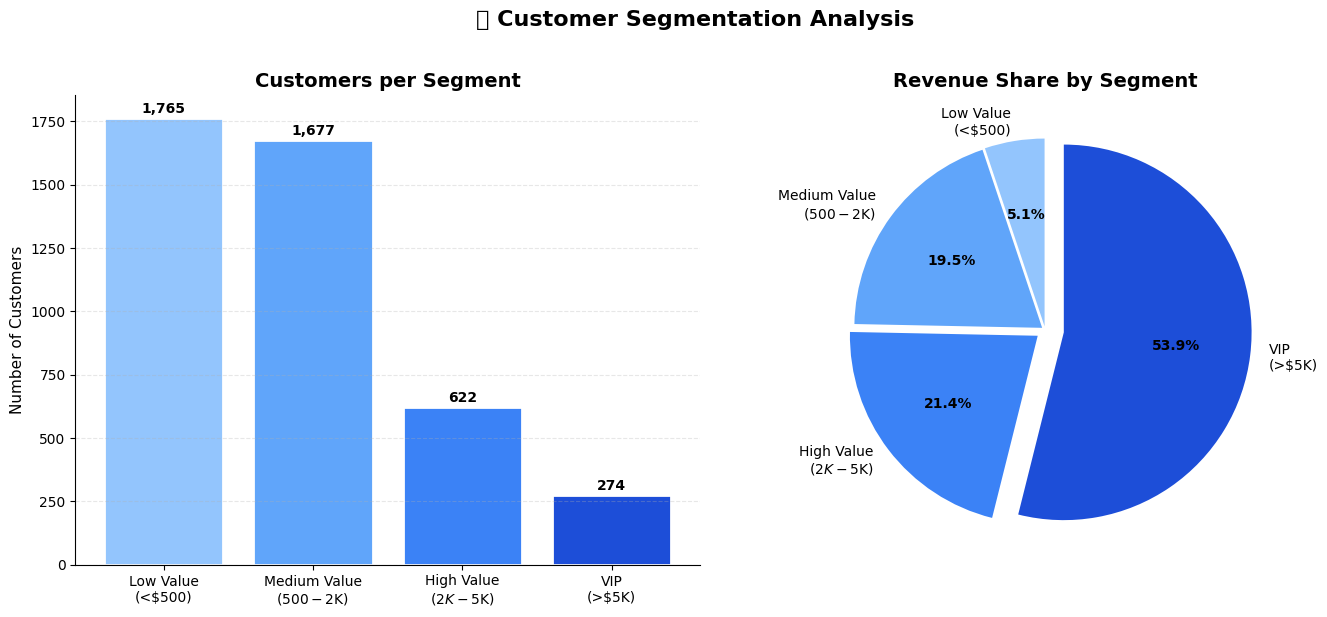

Low Value
(<$500): 1,765 customers, $457,267.47 revenue
Medium Value
($500-$2K): 1,677 customers, $1,735,894.28 revenue
High Value
($2K-$5K): 622 customers, $1,903,392.81 revenue
VIP
(>$5K): 274 customers, $4,790,654.33 revenue


In [0]:
print("\n👥 CHART 4: Customer Segmentation")
print("-" * 40)

# Create segments based on spending
bins = [0, 500, 2000, 5000, float('inf')]
labels = ['Low Value\n(<$500)', 'Medium Value\n($500-$2K)', 
          'High Value\n($2K-$5K)', 'VIP\n(>$5K)']

customer_pdf['Segment'] = pd.cut(customer_pdf['Total_Spent'], 
                                  bins=bins, labels=labels)

segment_data = customer_pdf.groupby('Segment', observed=False).agg({
    'CustomerID': 'count',
    'Total_Spent': 'sum'
}).reset_index()

# Create charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart - Customer count
bar_colors = ['#93C5FD', '#60A5FA', '#3B82F6', '#1D4ED8']
bars = ax1.bar(segment_data['Segment'], segment_data['CustomerID'], 
               color=bar_colors, edgecolor='white', linewidth=2)

for bar, value in zip(bars, segment_data['CustomerID']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{value:,}', ha='center', fontweight='bold', fontsize=10)

ax1.set_title('Customers per Segment', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Customers', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

# Pie chart - Revenue share
pie_colors = ['#93C5FD', '#60A5FA', '#3B82F6', '#1D4ED8']
wedges, texts, autotexts = ax2.pie(
    segment_data['Total_Spent'],
    labels=segment_data['Segment'],
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    explode=[0.02, 0.02, 0.05, 0.1]
)

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax2.set_title('Revenue Share by Segment', fontsize=14, fontweight='bold')

plt.suptitle('👥 Customer Segmentation Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print segment details
for _, row in segment_data.iterrows():
    print(f"{row['Segment']}: {row['CustomerID']:,} customers, ${row['Total_Spent']:,.2f} revenue")


📅 CHART 5: Daily Revenue Performance
----------------------------------------


/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684197-4243461792:32: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


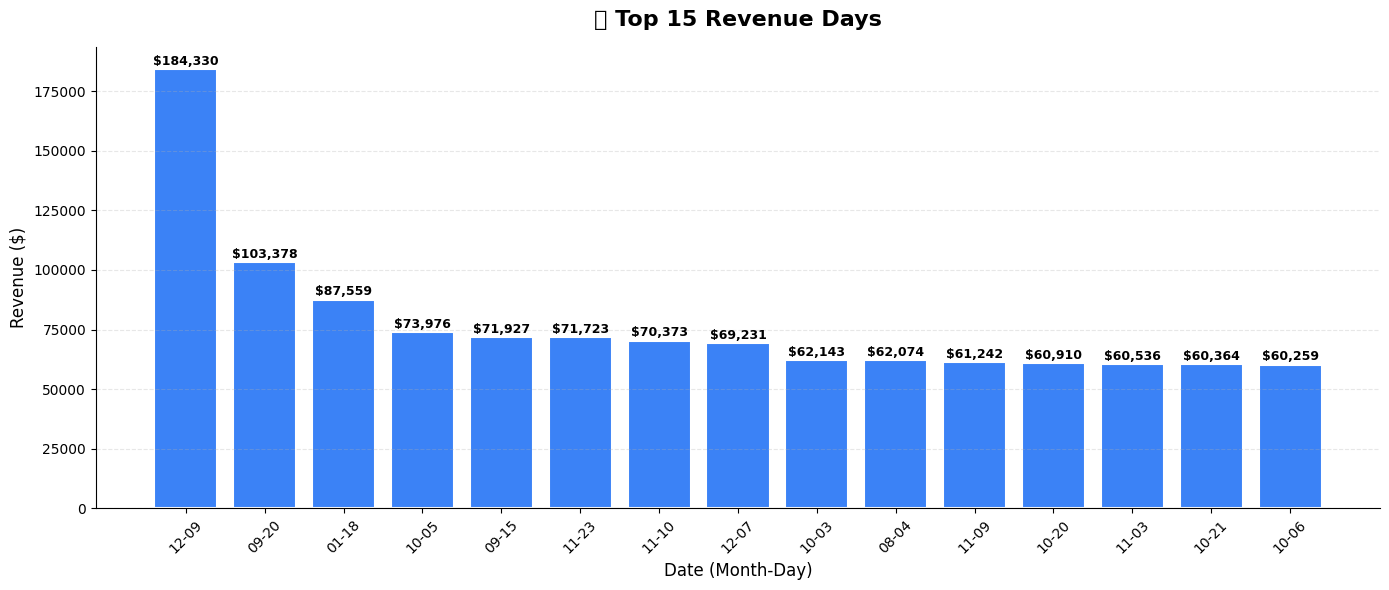

📅 Best Day: 12-09
   Revenue: $184,329.66
   Orders: 41


In [0]:
print("\n📅 CHART 5: Daily Revenue Performance")
print("-" * 40)

# Create month-day pivot table
daily_pdf['Date_Label'] = daily_pdf['Month'].astype(str).str.zfill(2) + '-' + \
                           daily_pdf['Day'].astype(str).str.zfill(2)

# Get top 15 days
top_days = daily_pdf.nlargest(15, 'Revenue')[['Date_Label', 'Revenue', 'Total_Orders']]

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(range(len(top_days)), top_days['Revenue'], 
              color='#3B82F6', edgecolor='white', linewidth=1.5)

# Add value labels
for bar, value in zip(bars, top_days['Revenue']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 500,
            f'${value:,.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(top_days)))
ax.set_xticklabels(top_days['Date_Label'], rotation=45)
ax.set_title('📅 Top 15 Revenue Days', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date (Month-Day)', fontsize=12)
ax.set_ylabel('Revenue ($)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

best_day = top_days.iloc[0]
print(f"📅 Best Day: {best_day['Date_Label']}")
print(f"   Revenue: ${best_day['Revenue']:,.2f}")
print(f"   Orders: {best_day['Total_Orders']}")


🎯 CHART 6: Key Performance Indicators
----------------------------------------


/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684198-3115324522:51: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684198-3115324522:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684198-3115324522:51: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684198-3115324522:51: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684198-3115324522:51: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/spark-4c59473c

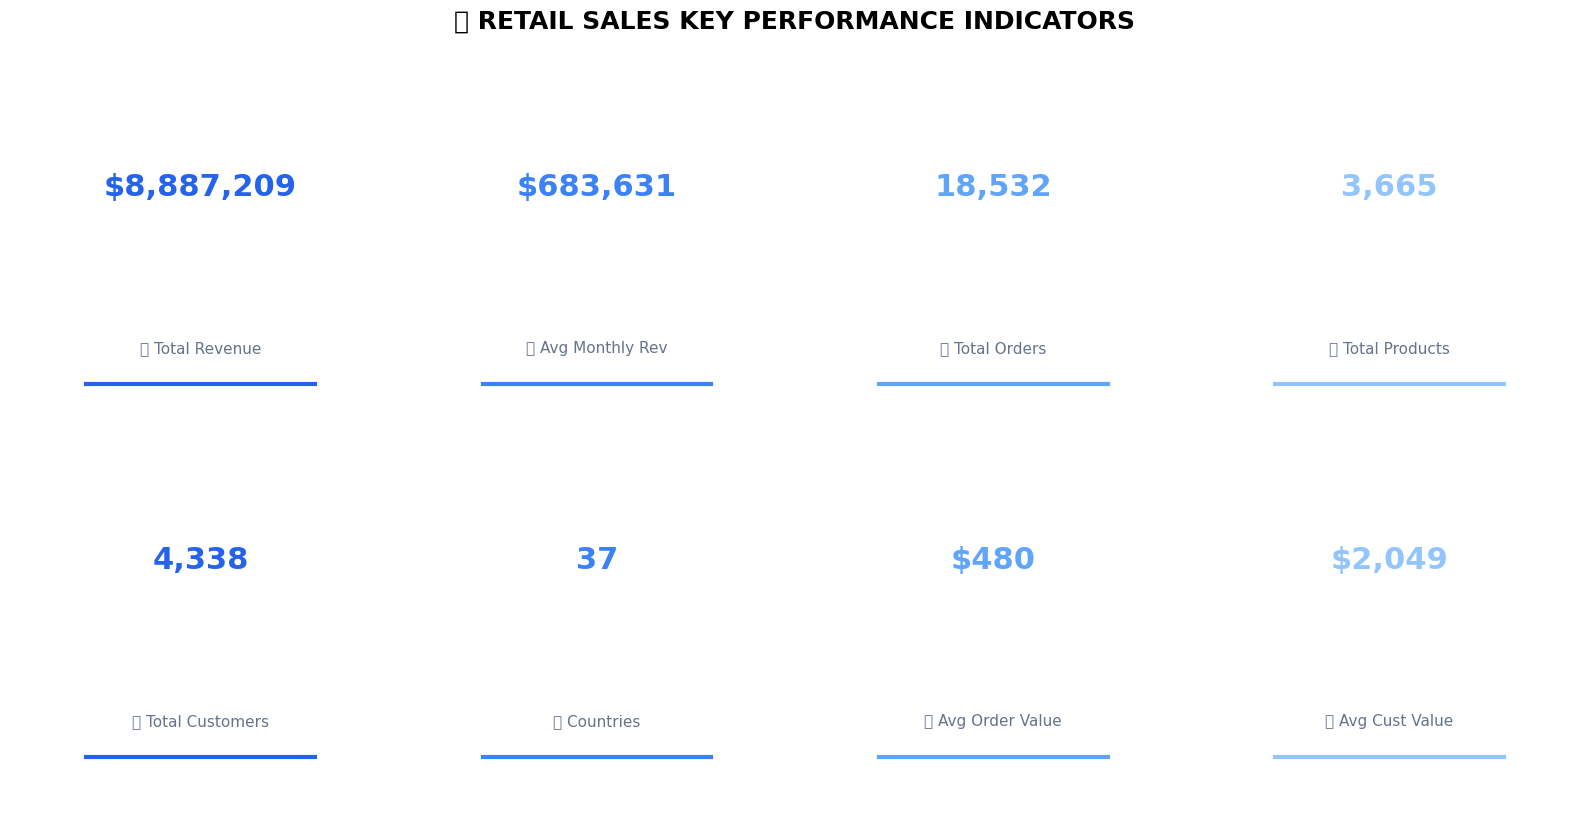

In [0]:
print("\n🎯 CHART 6: Key Performance Indicators")
print("-" * 40)

# Calculate all KPIs
total_revenue = monthly_pdf['Monthly_Revenue'].sum()
total_orders = monthly_pdf['Monthly_Orders'].sum()
total_customers = customer_pdf['CustomerID'].nunique()
total_products = product_pdf['StockCode'].nunique()
total_countries = country_pdf['Country'].nunique()
avg_order_value = total_revenue / total_orders
avg_customer_value = total_revenue / total_customers

# Create KPI dashboard
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('🎯 RETAIL SALES KEY PERFORMANCE INDICATORS', 
             fontsize=18, fontweight='bold', y=1.02)

# KPI data
kpis = [
    ('💰 Total Revenue', f'${total_revenue:,.0f}', '#2563EB'),
    ('📊 Avg Monthly Rev', f'${total_revenue/len(monthly_pdf):,.0f}', '#3B82F6'),
    ('🛒 Total Orders', f'{total_orders:,}', '#60A5FA'),
    ('📦 Total Products', f'{total_products:,}', '#93C5FD'),
    ('👥 Total Customers', f'{total_customers:,}', '#2563EB'),
    ('🌍 Countries', f'{total_countries}', '#3B82F6'),
    ('💵 Avg Order Value', f'${avg_order_value:,.0f}', '#60A5FA'),
    ('👤 Avg Cust Value', f'${avg_customer_value:,.0f}', '#93C5FD'),
]

# Flatten axes for easy iteration
axes_flat = axes.flatten()

for ax, (title, value, color) in zip(axes_flat, kpis):
    ax.text(0.5, 0.7, value, ha='center', va='center', 
            fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.25, title, ha='center', va='center', 
            fontsize=11, color='#64748B')
    
    # Add a colored line at bottom
    ax.axhline(y=0.15, xmin=0.2, xmax=0.8, color=color, linewidth=3)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

# Remove any extra subplots
if len(kpis) < len(axes_flat):
    for ax in axes_flat[len(kpis):]:
        ax.axis('off')

plt.tight_layout()
plt.show()


📈 CHART 7: Month-over-Month Growth
----------------------------------------


/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684199-3014389594:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly_pdf['Label'], rotation=45)
/home/spark-4c59473c-274f-4329-979f-3c/.ipykernel/12590/command-7281802692684199-3014389594:41: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


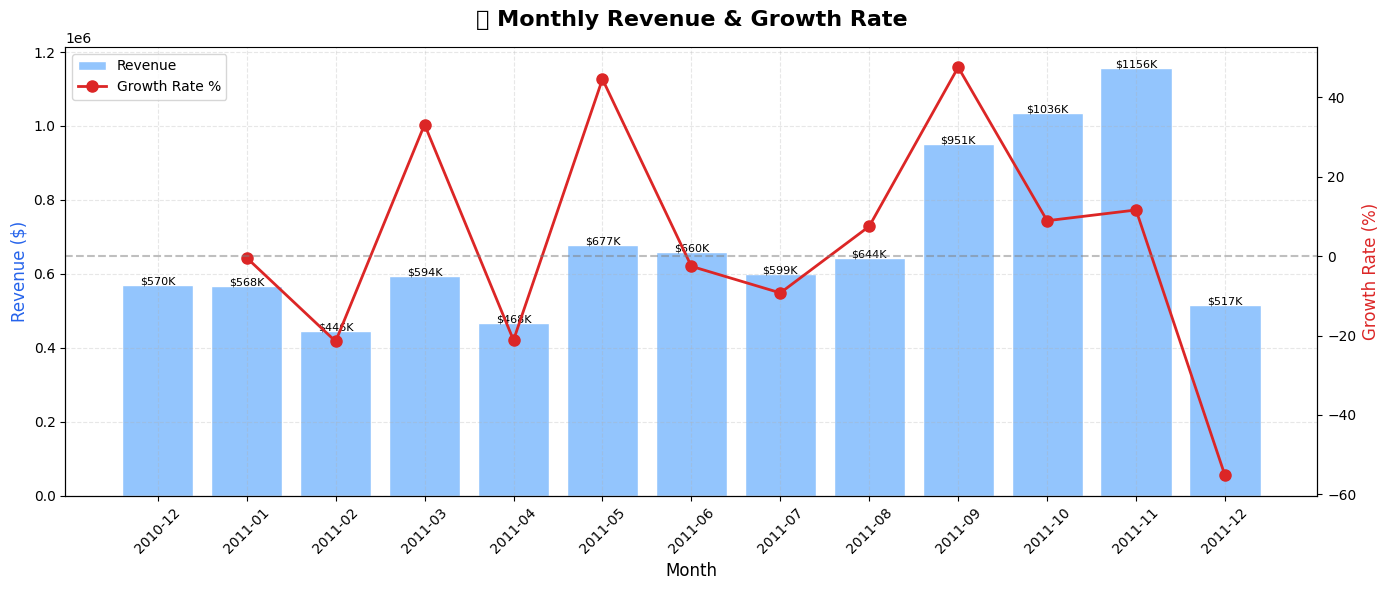

📈 Average Monthly Growth: 3.6%


In [0]:
print("\n📈 CHART 7: Month-over-Month Growth")
print("-" * 40)

# Calculate growth rate
monthly_pdf = monthly_pdf.sort_values(['Year', 'Month'])
monthly_pdf['Growth_Rate'] = monthly_pdf['Monthly_Revenue'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for revenue
bars = ax1.bar(monthly_pdf['Label'], monthly_pdf['Monthly_Revenue'],
               color='#93C5FD', edgecolor='white', label='Revenue')

# Line chart for growth rate
ax2 = ax1.twinx()
ax2.plot(monthly_pdf['Label'], monthly_pdf['Growth_Rate'],
         marker='o', color='#DC2626', linewidth=2, markersize=8,
         label='Growth Rate %')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Style
ax1.set_title('📈 Monthly Revenue & Growth Rate', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Revenue ($)', fontsize=12, color='#2563EB')
ax2.set_ylabel('Growth Rate (%)', fontsize=12, color='#DC2626')
ax1.set_xticklabels(monthly_pdf['Label'], rotation=45)

# Add value labels on bars
for bar, value in zip(bars, monthly_pdf['Monthly_Revenue']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${value/1000:.0f}K', ha='center', fontsize=8)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(True, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

# Growth summary
avg_growth = monthly_pdf['Growth_Rate'].dropna().mean()
print(f"📈 Average Monthly Growth: {avg_growth:.1f}%")

In [0]:
print("\n" + "=" * 60)
print("🎉 DASHBOARD COMPLETE!")
print("=" * 60)
print()
print("📊 7 Charts Created:")
print("   1. 📈 Monthly Revenue Trend")
print("   2. 🏆 Top 10 Products")
print("   3. 🌍 Sales by Country")
print("   4. 👥 Customer Segments")
print("   5. 📅 Top Revenue Days")
print("   6. 🎯 KPI Summary")
print("   7. 📈 Revenue Growth Rate")
print()
print("💰 KEY METRICS:")
print(f"   Total Revenue: ${total_revenue:,.2f}")
print(f"   Total Orders: {total_orders:,}")
print(f"   Total Customers: {total_customers:,}")
print(f"   Total Products: {total_products:,}")
print(f"   Countries Served: {total_countries}")
print(f"   Avg Order Value: ${avg_order_value:,.2f}")
print(f"   Avg Customer Value: ${avg_customer_value:,.2f}")
print()
print("=" * 60)
print("🎯 PROJECT COMPLETE!")
print("=" * 60)
print()
print("✅ All 6 Notebooks Done:")
print("   01_data_ingestion_bronze ✅")
print("   02_data_cleaning_silver ✅")
print("   03_business_tables_gold ✅")
print("   04_sql_analytics ✅")
print("   05_ml_forecasting ✅")
print("   06_dashboard ✅")
print()
print("📁 Next Steps:")
print("   1. Create README.md")
print("   2. Export notebooks")
print("   3. Push to GitHub")
print("   4. Add to Resume")
print("=" * 60)


🎉 DASHBOARD COMPLETE!

📊 7 Charts Created:
   1. 📈 Monthly Revenue Trend
   2. 🏆 Top 10 Products
   3. 🌍 Sales by Country
   4. 👥 Customer Segments
   5. 📅 Top Revenue Days
   6. 🎯 KPI Summary
   7. 📈 Revenue Growth Rate

💰 KEY METRICS:
   Total Revenue: $8,887,208.89
   Total Orders: 18,532
   Total Customers: 4,338
   Total Products: 3,665
   Countries Served: 37
   Avg Order Value: $479.56
   Avg Customer Value: $2,048.69

🎯 PROJECT COMPLETE!

✅ All 6 Notebooks Done:
   01_data_ingestion_bronze ✅
   02_data_cleaning_silver ✅
   03_business_tables_gold ✅
   04_sql_analytics ✅
   05_ml_forecasting ✅
   06_dashboard ✅

📁 Next Steps:
   1. Create README.md
   2. Export notebooks
   3. Push to GitHub
   4. Add to Resume
